# Chapter 5 — Pretraining on unlabeled data

Chapter 4 assembled a complete GPT architecture. This chapter measures its initial behavior, prepares language-model training data,
and develops the training loop needed to learn next-token prediction from unlabeled text.

In [1]:
#| default_exp training

In [2]:
#| export
import matplotlib.pyplot as plt
import tiktoken
import torch
from matplotlib.ticker import MaxNLocator
from torch.utils.data import DataLoader

from build_llms_from_scratch_companion.generation import generate_text_simple
from build_llms_from_scratch_companion.model import GPTModel

## 5.1 Preparing an untrained GPT baseline

Instantiate the Chapter 4 `GPTModel` before changing any weights. GPT-2 small normally supports 1,024 tokens, but this chapter uses a
shorter `context_length=256` to reduce computation during learning experiments. The other architecture dimensions remain those of
GPT-2 small.

Calling `model.eval()` disables dropout for the baseline generation. It does not train the model or make its random parameters
meaningful; it only makes repeated inference deterministic.

In [3]:
from build_llms_from_scratch_companion.model import GPTConfig

# Use GPT-2 small dimensions with a shorter context length for this chapter.
GPT_CONFIG_124M = GPTConfig(
    vocab_size=50257,
    context_length=256,
    emb_dim=768,
    num_heads=12,
    num_layers=12,
    dropout_rate=0.1,
    qkv_bias=False,
)

# Reproduce the random initialization used for the pretraining baseline.
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
# Disable all dropout while evaluating text generation before training.
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

## 5.2 Converting between text and batched token IDs

The generation helper operates on token-ID tensors, while examples begin and end as text. Two small conversion helpers establish the
boundary:

```text
text -> tokenizer.encode -> (num_tokens,) -> unsqueeze(0)
     -> (batch_size=1, num_tokens)

(batch_size=1, num_tokens) -> squeeze(0) -> (num_tokens,)
     -> tokenizer.decode -> text
```

Allowing `<|endoftext|>` explicitly lets later chapter examples encode document boundaries with the GPT-2 tokenizer.

In [4]:
#| export
def text_to_token_ids(
    text: str,
    tokenizer: tiktoken.Encoding,
) -> torch.Tensor:
    """Encode one text string as a batch containing one token-ID sequence.

    Args:
        text: Text to encode into GPT-2 token IDs.
        tokenizer: Tokenizer that maps text to token IDs.

    Returns:
        Token IDs shaped `(batch_size=1, num_tokens)`.
    """
    # encoded contains num_tokens integer token IDs.
    encoded = tokenizer.encode(text, allowed_special={"<|endoftext|>"})
    # (num_tokens,) -> (batch_size=1, num_tokens)
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)
    return encoded_tensor


def token_ids_to_text(
    token_ids: torch.Tensor,
    tokenizer: tiktoken.Encoding,
) -> str:
    """Decode a batch containing one token-ID sequence back into text.

    Args:
        token_ids: Token IDs shaped `(batch_size=1, num_tokens)`.
        tokenizer: Tokenizer that maps token IDs back to text.

    Returns:
        Decoded text for the single sequence in the batch.
    """
    # Remove the size-one batch dimension: (1, num_tokens) -> (num_tokens,).
    flat = token_ids.squeeze(0)
    return tokenizer.decode(flat.tolist())

### Generating text before pretraining

Generate ten token IDs from a four-token prompt to establish the model's initial behavior. The result has fourteen token positions,
and the original four prompt tokens remain at the beginning.

Because the model is randomly initialized, incoherent text is expected. Pretraining will adjust its parameters so the next-token
logits increasingly reflect patterns in the training text.

In [5]:
start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")
# input_ids: (batch_size=1, num_tokens=4)
input_ids = text_to_token_ids(start_context, tokenizer)
# token_ids: (batch_size=1, num_tokens=4 + max_new_tokens=10)
token_ids = generate_text_simple(
    model=model,
    idx=input_ids,
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M.context_length,
)
print("Output text:")
print(token_ids_to_text(token_ids, tokenizer))

Output text:
Every effort moves you rentingetic wasnم refres RexMeCHicular stren


## 5.3 Preparing inputs and targets for next-token prediction

Language-model pretraining uses the text itself as supervision. Each input token asks the model to predict the token immediately
after it. Begin with two short sequences arranged as a `(batch_size=2, num_tokens=3)` tensor.

In [6]:
# inputs: (batch_size=2, num_tokens=3)
# Each row contains one three-token input sequence.
inputs = torch.tensor(
    [
        [16833, 3626, 6100],  # "every effort moves"
        [40, 1107, 588],  # "I really like"
    ]
)

### Shifting inputs to create targets

Targets contain the same text shifted forward by one position:

```text
input:   every  effort  moves
target:         effort  moves  you
```

Input and target tensors have identical `(batch_size, num_tokens)` shapes, but each aligned pair represents one next-token training
example. Two rows of three positions therefore provide six predictions for the loss.

In [7]:
# targets: (batch_size=2, num_tokens=3)
# Each target row is its input row shifted one token forward.
targets = torch.tensor(
    [
        [3626, 6100, 345],  # " effort moves you"
        [1107, 588, 11311],  # " really like chocolate"
    ]
)

## 5.4 Converting logits into token probabilities

The model processes every input position in parallel and returns one unnormalized score for every vocabulary entry. Applying softmax
along the final `vocab_size` dimension turns each score vector into a probability distribution whose values sum to one:

```text
inputs   (batch_size, num_tokens)
logits   (batch_size, num_tokens, vocab_size)
probas   (batch_size, num_tokens, vocab_size)
```

In [8]:
# Evaluate the untrained model without constructing a gradient graph.
with torch.no_grad():
    # logits: (batch_size=2, num_tokens=3, vocab_size=50_257)
    logits = model(inputs)
# Normalize each position's vocabulary logits independently.
# probas: (batch_size=2, num_tokens=3, vocab_size=50_257)
probas = torch.softmax(logits, dim=-1)
probas.shape

torch.Size([2, 3, 50257])

### Inspecting greedy predictions at every position

Apply `argmax` across `vocab_size` to inspect the model's most probable token ID at each input position. Unlike generation, which uses
only the final position, loss calculation evaluates all positions in parallel.

Keeping the reduced dimension produces `(batch_size, num_tokens, 1)` rather than `(batch_size, num_tokens)`.

In [9]:
# Select the highest-probability vocabulary entry at every position.
# token_ids: (batch_size=2, num_tokens=3, 1)
token_ids = torch.argmax(probas, dim=-1, keepdim=True)
print("Token IDs:")
print(token_ids)

Token IDs:
tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])


### Comparing predicted and target text

Decode the first row's expected and predicted token IDs. The random model's predictions differ from the targets, which is expected
before pretraining. Flattening the prediction removes the trailing size-one dimension required only by the preceding `argmax`
example.

In [10]:
# targets[0]: (num_tokens=3,)
print(f"Targets batch 1: {token_ids_to_text(targets[0], tokenizer)}")
# token_ids[0]: (num_tokens=3, 1) -> flatten(): (num_tokens=3,)
print(f"Outputs batch 1: {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

Targets batch 1:  effort moves you
Outputs batch 1:  Armed heNetflix


## 5.5 Extracting the correct-token probabilities

Training does not optimize only the model's largest prediction. For every position, it selects the probability assigned to the known
`target_ids` value.

The three index components identify matching coordinates in `probas`:

```text
probas[text_idx, token positions, target token IDs]
       one row     [0, 1, 2]    one ID per position
```

This advanced indexing returns one correct-token probability per position, shaped `(num_tokens,)`. An untrained model assigns very
small probabilities to these targets because its probability mass is spread across `vocab_size=50_257` possibilities.

In [11]:
# Select the probability assigned to each correct target token in row 0.
text_idx = 0
# target_probas_1: (num_tokens=3,)
target_probas_1 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 1:", target_probas_1)

# Repeat the same position-by-position lookup for row 1.
text_idx = 1
# target_probas_2: (num_tokens=3,)
target_probas_2 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 2:", target_probas_2)

Text 1: tensor([7.4540e-05, 3.1061e-05, 1.1563e-05])
Text 2: tensor([1.0337e-05, 5.6776e-05, 4.7559e-06])


## 5.6 Calculating the language-model loss manually

Probabilities multiply across independent predictions, which can quickly underflow toward zero. Taking the natural logarithm converts
products into sums and makes the training objective numerically easier to work with.

Concatenate the correct-token probabilities from both rows, then apply `log` element-wise. Six input positions produce six log
probabilities.

In [12]:
# Combine the three target probabilities from each batch row.
# target_probas_1 and target_probas_2: (num_tokens=3,)
# log_probas: (batch_size * num_tokens=6,)
log_probas = torch.log(torch.cat((target_probas_1, target_probas_2)))
log_probas

tensor([ -9.5042, -10.3796, -11.3677, -11.4798,  -9.7764, -12.2561])

### Averaging across all token positions

Average the six log probabilities so the result does not scale with the number of training positions. Since every probability lies
between zero and one, every logarithm is zero or negative and their average is negative.

In [13]:
# Average across all six next-token predictions.
# avg_log_probas: scalar tensor with shape ()
avg_log_probas = torch.mean(log_probas)
print(avg_log_probas)

tensor(-10.7940)


### Converting the objective into a loss

Negate the average log probability to obtain **negative log-likelihood**. Training minimizes this positive scalar: increasing the
probability assigned to correct targets moves their logarithms toward zero and lowers the loss.

In [14]:
# Negate the average so lower loss means higher target probabilities.
# neg_avg_log_probas: scalar tensor with shape ()
neg_avg_log_probas = avg_log_probas * -1
print(neg_avg_log_probas)

tensor(10.7940)


## 5.7 Computing cross-entropy with PyTorch

PyTorch's `cross_entropy` computes the same negative average log probability directly from raw logits and integer target IDs. It
expects predictions shaped `(number_of_predictions, vocab_size)` and targets shaped `(number_of_predictions,)`.

Our model keeps batch and token dimensions separate, so they must first be combined into one prediction dimension.

### Inspecting the cross-entropy input shapes

Before flattening, logits retain separate batch and token dimensions while targets contain one vocabulary index for every matching
position. Cross-entropy needs the same six predictions, but expressed as a two-dimensional score matrix and a one-dimensional target
vector.

In [15]:
# logits: (batch_size=2, num_tokens=3, vocab_size=50_257)
print("Logits shape:", logits.shape)
# targets: (batch_size=2, num_tokens=3)
print("Targets shape:", targets.shape)

Logits shape: torch.Size([2, 3, 50257])
Targets shape: torch.Size([2, 3])


### Flattening batch and token dimensions

`flatten(0, 1)` merges only the first two logits dimensions and preserves `vocab_size`. Flattening targets merges their corresponding
batch and token dimensions:

```text
logits   (2, 3, 50_257) -> (6, 50_257)
targets  (2, 3)         -> (6,)
```

Row `i` in `logits_flat` remains aligned with target ID `i` in `targets_flat`.

In [16]:
# Merge batch_size and num_tokens into one prediction dimension.
# logits_flat: (batch_size * num_tokens=6, vocab_size=50_257)
logits_flat = logits.flatten(0, 1)
# targets_flat: (batch_size * num_tokens=6,)
targets_flat = targets.flatten()
print("Flattened logits:", logits_flat.shape)
print("Flattened targets:", targets_flat.shape)

Flattened logits: torch.Size([6, 50257])
Flattened targets: torch.Size([6])


### Verifying the built-in loss

`cross_entropy` applies log-softmax internally, selects the correct target log probabilities, negates them, and returns their mean.
Its scalar result should match the manually calculated negative average log probability.

In [17]:
# Cross-entropy combines log-softmax with negative log-likelihood.
# loss: scalar tensor with shape ()
loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
print(loss)

tensor(10.7940)


## 5.8 Loading a text corpus for pretraining

The small *The Verdict* corpus provides continuous text for the first training experiments. Read the UTF-8 file into one string; a
sliding-window dataset will later divide its token IDs into input and target sequences.

### Reading the source text

Open the local `the-verdict.txt` file with explicit UTF-8 decoding. At this stage, `text_data` is one Python string rather than a tensor;
tokenization happens when constructing the training dataset.

In [18]:
# Load the UTF-8 training text as one Python string.
file_path = "the-verdict.txt"
with open(file_path, encoding="utf-8") as file:
    text_data = file.read()

### Comparing character and token counts

Character count measures Unicode characters, whereas token count measures the subword units processed by GPT. These totals differ
because one token can represent a complete word, a word fragment, whitespace, or punctuation.

In [19]:
# Both values are scalar Python integers describing the complete corpus.
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))
print("Characters:", total_characters)
print("Tokens:", total_tokens)

Characters: 20479
Tokens: 5145


## 5.9 Splitting training and validation text

Use the first 90% of the corpus for parameter updates and reserve the final 10% for validation. Keeping the split contiguous avoids
mixing overlapping passages across both subsets.

The split operates on Python-string character offsets, not token positions. Each substring is tokenized independently when its data
loader is created.

In [20]:
# Reserve the final 10% of characters for validation.
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
# train_data and val_data are Python strings measured here in characters.
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]
len(train_data), len(val_data)

(18431, 2048)

## 5.10 Building training and validation data loaders

Create non-overlapping 256-token windows by setting `stride` equal to the configured `context_length`. Each complete batch contains two
independent windows:

```text
input_batch   (batch_size=2, num_tokens=256)
target_batch  (batch_size=2, num_tokens=256)
```

The small `batch_size=2` keeps the example inexpensive while making batching visible. Training shuffles windows and drops an incomplete
final batch so updates have consistent shapes. Validation preserves order and keeps its final batch because every held-out example is
useful for evaluation.

In [21]:
from build_llms_from_scratch_companion.data import create_dataloader_v1

# Make the shuffled training-window order reproducible.
torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M.context_length,
    stride=GPT_CONFIG_124M.context_length,
    drop_last=True,
    shuffle=True,
    num_workers=0,
)
val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M.context_length,
    stride=GPT_CONFIG_124M.context_length,
    drop_last=False,
    shuffle=False,
    num_workers=0,
)

### Inspecting loader shapes

Iterate once through both loaders to verify their contracts before training. Every target position is shifted one token ahead of the
matching input position, while batching preserves identical input and target shapes.

In [22]:
print("Train loader:")
for input_batch, target_batch in train_loader:
    # Complete training batches: (batch_size=2, num_tokens=256)
    print(input_batch.shape, target_batch.shape)

print("Validation loader:")
for input_batch, target_batch in val_loader:
    # Validation keeps the final batch even when it is incomplete.
    # Here both tensors are: (batch_size=2, num_tokens=256)
    print(input_batch.shape, target_batch.shape)

Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])


## 5.11 Calculating loss for one batch

`calc_loss_batch` is the device-aware boundary used by the future training loop. It moves input and target token IDs to the same device
as the model, computes vocabulary logits, flattens batch and token dimensions, and returns one scalar cross-entropy loss.

```text
input_batch    (batch_size, num_tokens)
target_batch   (batch_size, num_tokens)
logits         (batch_size, num_tokens, vocab_size)
flat logits    (batch_size * num_tokens, vocab_size)
flat targets   (batch_size * num_tokens,)
loss           ()
```

Moving a tensor between CPU and CUDA changes its storage location but not its shape.

In [23]:
#| export
def calc_loss_batch(
    input_batch: torch.Tensor,
    target_batch: torch.Tensor,
    model: GPTModel,
    device: torch.device,
) -> torch.Tensor:
    """Calculate cross-entropy for one batch on the selected device.

    Args:
        input_batch: Input token IDs shaped `(batch_size, num_tokens)`.
        target_batch: Target token IDs shaped `(batch_size, num_tokens)`.
        model: GPT model that maps input token IDs to vocabulary logits.
        device: CPU or CUDA device used for the tensors and model.

    Returns:
        Scalar cross-entropy loss with shape `()`.
    """
    # Device transfer preserves: (batch_size, num_tokens)
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    # logits: (batch_size, num_tokens, vocab_size)
    logits = model(input_batch)
    # Flatten to (batch_size * num_tokens, vocab_size) and
    # (batch_size * num_tokens,) for cross-entropy.
    loss = torch.nn.functional.cross_entropy(
        logits.flatten(0, 1),
        target_batch.flatten(),
    )
    return loss

## 5.12 Averaging loss across a data loader

One batch loss is noisy and may not represent the complete split. `calc_loss_loader` repeatedly calls `calc_loss_batch`, converts each
scalar tensor to a Python float with `.item()`, and returns the arithmetic mean.

The optional `num_batches` limit supports faster interim evaluation. It is capped at `len(data_loader)`, while `None` evaluates every
available batch. An empty loader has no valid average and therefore returns `nan`.

```text
one loader item:  input_batch, target_batch
                  each (batch_size, num_tokens)
one batch loss:   scalar tensor ()
loader loss:      scalar Python float
```

In [24]:
#| export
def calc_loss_loader(
    data_loader: DataLoader[tuple[torch.Tensor, torch.Tensor]],
    model: GPTModel,
    device: torch.device,
    num_batches: int | None = None,
) -> float:
    """Average cross-entropy across batches from one data loader.

    Args:
        data_loader: Loader yielding input and target token-ID batches, each
            shaped `(batch_size, num_tokens)`.
        model: GPT model used to calculate next-token logits.
        device: CPU or CUDA device used for the tensors and model.
        num_batches: Maximum number of batches to evaluate, or `None` to use
            the complete loader.

    Returns:
        Mean batch loss as a Python float, or `nan` for an empty loader.
    """
    # Accumulate scalar Python floats rather than retaining computation graphs.
    total_loss = 0.0
    if len(data_loader) == 0:
        return float("nan")
    if num_batches is None:
        num_batches = len(data_loader)
    else:
        # Never request more batches than the loader contains.
        num_batches = min(num_batches, len(data_loader))

    for i, (input_batch, target_batch) in enumerate(data_loader):
        # input_batch and target_batch: (batch_size, num_tokens)
        if i < num_batches:
            # loss: scalar tensor with shape ()
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

## 5.13 Evaluating the untrained baseline loss

Select CUDA when it is available, otherwise retain a CPU fallback. The model and each batch must occupy the same device; moving them
changes storage location but preserves all tensor shapes.

With `model.eval()` already active and `torch.no_grad()` surrounding evaluation, dropout is disabled and PyTorch does not retain
backpropagation graphs. `calc_loss_loader` returns one Python float for each split:

```text
loader input batches   (batch_size, num_tokens)
model logits           (batch_size, num_tokens, vocab_size)
each batch loss        scalar tensor ()
reported loader loss   scalar Python float
```

The randomly initialized model has similarly high training and validation losses. These values establish a controlled baseline; after
pretraining, both should decrease as the model assigns more probability to correct next tokens.

In [25]:
# Prefer the configured NVIDIA GPU and fall back to CPU when CUDA is unavailable.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Move every model parameter and registered buffer without changing its shape.
model.to(device)

# Baseline evaluation needs forward passes but no gradient graphs.
with torch.no_grad():
    # train_loss and val_loss are scalar Python floats.
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)
print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 10.987583266364204
Validation loss: 10.98110580444336


## 5.14 Training the language model

The training loop coordinates three responsibilities:

1. update model parameters from training batches;
2. periodically measure training and validation loss; and
3. generate a sample after each epoch to inspect qualitative progress.

Training and evaluation use the same tensor shapes, but different model modes. `model.train()` enables dropout and gradient-based
updates; `model.eval()` disables dropout for stable loss measurement and generation.

The typed helpers in this section are exported to `training.py` for reuse in larger-corpus experiments.

### Evaluating bounded portions of both loaders

Evaluation uses at most `eval_iter` batches from each split to control its cost during training. Every call starts fresh loader
iterators; it does not resume an iterator left partially consumed elsewhere. Because the training loader shuffles, a fresh iterator may
visit its windows in a new order, while validation remains ordered.

The helper temporarily selects evaluation mode and disables gradient tracking, then restores training mode before returning two Python
floats.

In [26]:
#| export
def evaluate_model(
    model: GPTModel,
    train_loader: DataLoader[tuple[torch.Tensor, torch.Tensor]],
    val_loader: DataLoader[tuple[torch.Tensor, torch.Tensor]],
    device: torch.device,
    eval_iter: int,
) -> tuple[float, float]:
    """Evaluate mean training and validation loss without updating parameters.

    Args:
        model: GPT model whose loss is being measured.
        train_loader: Loader yielding training input and target batches.
        val_loader: Loader yielding validation input and target batches.
        device: CPU or CUDA device shared by the model and each batch.
        eval_iter: Maximum number of batches evaluated from each loader.

    Returns:
        Mean training loss and mean validation loss as Python floats.
    """
    # Disable dropout so repeated evaluation uses deterministic model behavior.
    model.eval()
    with torch.no_grad():
        # Each loader creates a fresh iterator for this evaluation call.
        train_loss = calc_loss_loader(
            train_loader,
            model,
            device,
            num_batches=eval_iter,
        )
        val_loss = calc_loss_loader(
            val_loader,
            model,
            device,
            num_batches=eval_iter,
        )
    # Restore training behavior for the optimization loop.
    model.train()
    return train_loss, val_loss

### Generating a progress sample

A generated sample gives a qualitative signal that scalar losses cannot show. The position-embedding table determines the supported
context window, and the prompt begins as `(batch_size=1, num_tokens)` token IDs. Greedy generation appends 50 token IDs before the
complete sequence is decoded.

Generation runs in evaluation mode without gradient tracking, then restores training mode for the next epoch.

In [27]:
#| export
def generate_and_print_sample(
    model: GPTModel,
    tokenizer: tiktoken.Encoding,
    device: torch.device,
    start_context: str,
) -> None:
    """Generate and print one text sample without updating model parameters.

    Args:
        model: GPT model used for greedy token generation.
        tokenizer: Tokenizer used to encode and decode the sample.
        device: CPU or CUDA device shared by the model and token IDs.
        start_context: Prompt text that begins the generated sample.

    Returns:
        None.
    """
    model.eval()
    # The position-embedding table has one row per supported token position.
    context_size = model.pos_emb.weight.shape[0]
    # encoded: (batch_size=1, num_tokens)
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        # token_ids: (batch_size=1, num_tokens + max_new_tokens=50)
        token_ids = generate_text_simple(
            model=model,
            idx=encoded,
            max_new_tokens=50,
            context_size=context_size,
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    # Keep the sample on one output line for readable training logs.
    print(decoded_text.replace("\n", " "))
    model.train()

### Coordinating epochs and optimizer steps

For every training batch, the loop performs the standard optimization sequence:

```text
zero_grad -> forward loss -> backward -> optimizer step
```

`input_batch.numel()` counts `batch_size * num_tokens`, so `tokens_seen` measures how many input token positions have contributed to
updates. `global_step` counts optimizer updates independently of epoch boundaries. At each `eval_freq` interval, aligned training loss,
validation loss, and cumulative token count values are appended for later plotting.

In [28]:
#| export
def train_model_simple(
    model: GPTModel,
    train_loader: DataLoader[tuple[torch.Tensor, torch.Tensor]],
    val_loader: DataLoader[tuple[torch.Tensor, torch.Tensor]],
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    num_epochs: int,
    eval_freq: int,
    eval_iter: int,
    start_context: str,
    tokenizer: tiktoken.Encoding,
) -> tuple[list[float], list[float], list[int]]:
    """Train a GPT model and periodically record loss and generated text.

    Args:
        model: GPT model whose parameters are updated.
        train_loader: Loader yielding training input and target batches.
        val_loader: Loader yielding validation input and target batches.
        optimizer: Optimizer that updates model parameters from gradients.
        device: CPU or CUDA device shared by the model and each batch.
        num_epochs: Number of complete passes through the training loader.
        eval_freq: Number of optimizer steps between loss evaluations.
        eval_iter: Maximum number of batches used for each evaluation.
        start_context: Prompt used for the sample generated after each epoch.
        tokenizer: Tokenizer used to encode and decode generated samples.

    Returns:
        Training losses, validation losses, and cumulative token counts
        recorded at each evaluation step.
    """
    train_losses: list[float] = []
    val_losses: list[float] = []
    track_tokens_seen: list[int] = []
    tokens_seen, global_step = 0, -1

    for epoch in range(num_epochs):
        model.train()
        # Iterating over train_loader starts a fresh, shuffled dataset pass.
        for input_batch, target_batch in train_loader:
            # input_batch and target_batch: (batch_size, num_tokens)
            optimizer.zero_grad()
            # loss: scalar tensor with shape ()
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            # Populate gradients for every trainable model parameter.
            loss.backward()
            optimizer.step()
            # numel() equals batch_size * num_tokens for this input batch.
            tokens_seen += input_batch.numel()
            global_step += 1

            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model,
                    train_loader,
                    val_loader,
                    device,
                    eval_iter,
                )
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(
                    f"Ep {epoch + 1} (Step {global_step:06d}): "
                    f"Train loss {train_loss:.3f}, "
                    f"Val loss {val_loss:.3f}"
                )

        generate_and_print_sample(model, tokenizer, device, start_context)
    return train_losses, val_losses, track_tokens_seen

## 5.15 Running pretraining

Create a freshly initialized GPT model and optimize it for ten complete passes through the training loader. AdamW combines gradient
updates with weight decay; here the learning rate controls update size and `weight_decay=0.1` discourages unnecessarily large weights.

Loss is evaluated every five optimizer steps using up to five batches from each split. The returned lists remain aligned:

```text
train_losses[i]  validation-time training loss
val_losses[i]    validation loss at the same optimizer step
tokens_seen[i]   cumulative input token positions at that step
```

On this very small corpus, training loss falls much faster than validation loss. The generated samples increasingly resemble the
training text, while the late validation-loss increase signals overfitting rather than continued generalization.

In [29]:
# Reinitialize the model so training starts from reproducible random weights.
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
# Move parameters and buffers to the selected CPU or CUDA device.
model.to(device)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.0004,
    weight_decay=0.1,
)
num_epochs = 10
# Each returned list has one entry per evaluation step.
train_losses, val_losses, tokens_seen = train_model_simple(
    model,
    train_loader,
    val_loader,
    optimizer,
    device,
    num_epochs=num_epochs,
    eval_freq=5,
    eval_iter=5,
    start_context="Every effort moves you",
    tokenizer=tokenizer,
)

Ep 1 (Step 000000): Train loss 9.822, Val loss 9.931
Ep 1 (Step 000005): Train loss 8.065, Val loss 8.337
Every effort moves you,,,,,,,,,,,,,,.                                   
Ep 2 (Step 000010): Train loss 6.623, Val loss 7.053
Ep 2 (Step 000015): Train loss 6.046, Val loss 6.602
Every effort moves you, the,, and,,,,,,,,,.                                   
Ep 3 (Step 000020): Train loss 5.556, Val loss 6.499
Ep 3 (Step 000025): Train loss 5.478, Val loss 6.398
Every effort moves you, and, and of the of the of the, and of the of the of the Stroud, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and
Ep 4 (Step 000030): Train loss 5.060, Val loss 6.313
Ep 4 (Step 000035): Train loss 4.760, Val loss 6.307
Every effort moves you a the picture.    "I had been the picture.             "I"I had the picture.              
Ep 5 (Step 000040): Train loss 4.185, Val loss 6.167
Every effort moves you know the "Oh, and he had to me--as of the donkey.           "Oh, and I f

## 5.16 Plotting the learning curves

Plot training and validation loss against epoch progress, then add cumulative token count as a second x-axis. Every sequence passed to
`plot_losses` contains one value per evaluation:

```text
epochs_seen   (num_evaluations,)
tokens_seen   num_evaluations Python integers
train_losses  num_evaluations Python floats
val_losses    num_evaluations Python floats
```

The transparent curve on the top axis is not additional data; it establishes the token-count coordinate range while leaving the two
visible loss curves unchanged. Comparing the curves makes the widening generalization gap easier to see.

In [30]:
#| export
def plot_losses(
    epochs_seen: torch.Tensor,
    tokens_seen: list[int],
    train_losses: list[float],
    val_losses: list[float],
) -> None:
    """Plot training and validation loss against epochs and tokens seen.

    Args:
        epochs_seen: Epoch coordinates shaped `(num_evaluations,)`.
        tokens_seen: Cumulative token counts at each evaluation step.
        train_losses: Mean training losses at each evaluation step.
        val_losses: Mean validation losses at each evaluation step.

    Returns:
        None.
    """
    # All four inputs contain num_evaluations aligned values.
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(
        epochs_seen,
        val_losses,
        linestyle="-.",
        label="Validation loss",
    )
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    # Epoch labels represent whole passes through the training loader.
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))

    # Add a second x-axis showing cumulative token positions processed.
    ax2 = ax1.twiny()
    # The invisible curve aligns the top axis with the loss measurements.
    ax2.plot(tokens_seen, train_losses, alpha=0)
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()

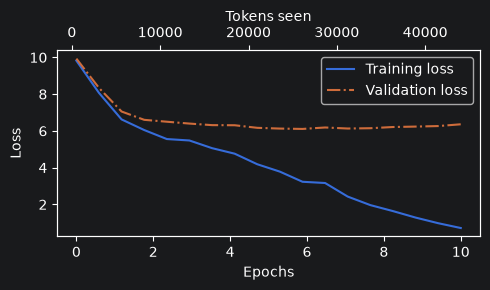

In [31]:
# epochs_tensor: (num_evaluations,)
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

test inference

In [32]:
# Move every parameter and registered buffer from CUDA to CPU.
# Device transfer changes storage location but preserves all tensor shapes.
model.to("cpu")
# Disable embedding, attention, and shortcut-branch dropout for inference.
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [33]:
tokenizer = tiktoken.get_encoding("gpt2")
# Input token IDs: (batch_size=1, num_tokens=4)
input_ids = text_to_token_ids("Every effort moves you", tokenizer)
# token_ids: (batch_size=1, num_tokens=4 + max_new_tokens=25)
token_ids = generate_text_simple(
    model=model,
    idx=input_ids,
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M.context_length,
)
# Remove the batch dimension and decode all 29 token IDs as text.
print("Output text:")
print(token_ids_to_text(token_ids, tokenizer))

Output text:
Every effort moves you?"

"Yes--quite insensible to the irony. She wanted him vindicated--and by me!"




## 5.18 Moving beyond greedy decoding

Greedy decoding always chooses the vocabulary entry with the largest probability. It is deterministic and easy to inspect, but it can
produce repetitive text because lower-probability alternatives are never considered.

Probabilistic decoding instead samples a token ID according to the complete vocabulary distribution. High-probability tokens remain
more likely, but other tokens can occasionally be selected. A nine-token toy vocabulary makes that distinction visible before applying
sampling to the full `vocab_size=50_257` model output.

### Creating a toy vocabulary

Map nine readable tokens to integer vocabulary IDs. The inverse mapping is needed because sampling returns IDs, while people interpret
the corresponding token strings.

In [34]:
# Map nine toy tokens to vocabulary IDs in [0, vocab_size).
vocab = {
    "closer": 0,
    "every": 1,
    "effort": 2,
    "forward": 3,
    "inches": 4,
    "moves": 5,
    "pizza": 6,
    "toward": 7,
    "you": 8,
}
# Reverse the lookup so sampled token IDs can be printed as text.
inverse_vocab = {token_id: token for token, token_id in vocab.items()}

### Defining one next-token logit vector

Treat the nine values as the model's final-position logits for one sequence. The vector has one score per toy vocabulary entry:

```text
next_token_logits  (vocab_size=9,)
```

Logits can be positive or negative and do not sum to one. Only their relative values affect the resulting probabilities.

In [35]:
# next_token_logits: (vocab_size=9,)
# Each value is the unnormalized score for the matching vocabulary ID.
next_token_logits = torch.tensor([4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79])

### Recovering greedy decoding

Softmax converts the nine logits into probabilities, and `argmax` chooses the largest one. Since softmax preserves score ordering,
applying `argmax` to logits or probabilities selects the same token ID.

In [36]:
# Normalize across all nine vocabulary entries.
# probas: (vocab_size=9,), with values summing to 1
probas = torch.softmax(next_token_logits, dim=0)
# argmax returns the vocabulary ID with the largest probability.
next_token_id = torch.argmax(probas).item()
print(inverse_vocab[next_token_id])

forward


### Sampling instead of taking `argmax`

`torch.multinomial` interprets `probas` as sampling weights. It does not choose uniformly: tokens with larger probabilities occupy more
of the distribution and are selected more often. Setting the seed makes this single demonstration reproducible.

In [37]:
# Fix the random-number sequence so this sampling example is reproducible.
torch.manual_seed(123)
# multinomial returns one sampled ID shaped (1,); item() extracts the scalar.
next_token_id = torch.multinomial(probas, num_samples=1).item()
print(inverse_vocab[next_token_id])

forward


### Observing the distribution empirically

One sample does not reveal the full distribution. Draw 1,000 token IDs with replacement and count them. Frequent results should
correspond to high model probabilities, while low-probability tokens may appear rarely or not at all.

In [38]:
def print_sampled_tokens(probas: torch.Tensor) -> None:
    """Sample repeatedly and print each toy token's empirical frequency.

    Args:
        probas: Vocabulary probabilities shaped `(vocab_size,)`.

    Returns:
        None.
    """
    torch.manual_seed(123)
    # sample contains 1,000 scalar vocabulary IDs drawn with replacement.
    sample = [torch.multinomial(probas, num_samples=1).item() for _ in range(1_000)]
    # sampled_ids: (vocab_size=9,), including zero counts for unsampled IDs
    sampled_ids = torch.bincount(
        torch.tensor(sample),
        minlength=len(inverse_vocab),
    )
    for token_id, frequency in enumerate(sampled_ids):
        print(f"{frequency} x {inverse_vocab[token_id]}")


print_sampled_tokens(probas)

73 x closer
0 x every
0 x effort
582 x forward
2 x inches
0 x moves
0 x pizza
343 x toward
0 x you


## 5.19 Controlling randomness with temperature

Temperature rescales logits before softmax:

```text
probas = softmax(logits / temperature)
```

- `temperature = 1` leaves the distribution unchanged.
- `temperature < 1` enlarges score differences and sharpens the distribution.
- `temperature > 1` reduces score differences and flattens the distribution.

Temperature must be positive. Values near zero approach greedy behavior, while high values increase diversity and the risk of selecting
unlikely tokens.

In [39]:
def softmax_with_temperature(
    logits: torch.Tensor,
    temperature: float,
) -> torch.Tensor:
    """Convert logits into probabilities after temperature scaling.

    Args:
        logits: Unnormalized vocabulary scores shaped `(vocab_size,)`.
        temperature: Positive scale controlling distribution sharpness.

    Returns:
        Vocabulary probabilities shaped `(vocab_size,)`.
    """
    # Division preserves (vocab_size,) while changing relative score gaps.
    scaled_logits = logits / temperature
    return torch.softmax(scaled_logits, dim=0)

### Comparing temperature distributions

Plot the probability assigned to every toy token at three temperatures. The low-temperature bars concentrate around the strongest
logit, whereas the high-temperature bars become more even. Temperature changes probabilities—not vocabulary IDs or tensor shape.

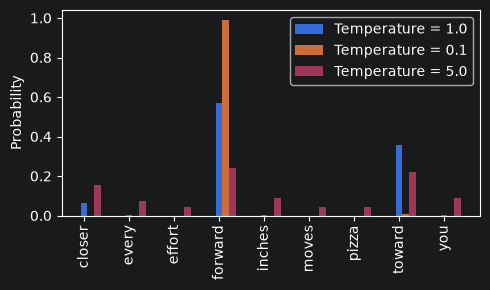

In [40]:
# Compare the original distribution with sharper and flatter alternatives.
temperatures = [1.0, 0.1, 5.0]
# Each tensor in scaled_probas: (vocab_size=9,)
scaled_probas = [
    softmax_with_temperature(next_token_logits, temperature) for temperature in temperatures
]
# x: (vocab_size=9,), one bar-group location per toy token
x = torch.arange(len(vocab))
bar_width = 0.15
fig, ax = plt.subplots(figsize=(5, 3))
for i, temperature in enumerate(temperatures):
    # Offset each temperature's bars so all distributions remain visible.
    ax.bar(
        x + i * bar_width,
        scaled_probas[i],
        bar_width,
        label=f"Temperature = {temperature}",
    )
ax.set_ylabel("Probability")
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

## Chapter 5 summary

The chapter now covers pretraining and the first decoding controls:

- shifted targets and cross-entropy provide the next-token learning objective;
- AdamW training lowers loss and changes generated text;
- greedy decoding always selects the highest-probability vocabulary ID;
- multinomial sampling draws token IDs according to all vocabulary probabilities; and
- temperature controls whether that sampling distribution is sharper or flatter.

The tiny corpus demonstrates mechanics and memorization; larger-corpus training and richer decoding strategies are needed for more
useful language generation.